In [38]:
from tensorflow import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

# 데이터 정규화 
train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0
# 채널이 하나 (흑백) | (Dimension, Row, Column, Channel) | 컬러일 경우 Channel을 3으로 함 (RGB)

train_scaled, val_scaled, train_target, val_target = \
    train_test_split(
        train_scaled,
        train_target,
        test_size=0.2,
        random_state=42
    )

#### 합성곱 (CNN) 층 만들기

In [39]:
model = keras.Sequential()

In [40]:
model.add(
    keras.layers.Conv2D(
        32, # Filter의 갯수 | 임의로 지정
        kernel_size=3, # 보통 정사각형으로 구성된다
        activation='relu', # 활성화 함수
        padding='same', # 원본 이미지 크기와 똑같이 형성
        input_shape=(28, 28, 1) # 입력값
    )
)

c:\Users\tuxca\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### 풀링층 (Pooling)

In [41]:
model.add(
    keras.layers.MaxPooling2D(2) # 2*2 max pooling
)
# 최대풀링을 추가해서 하나의 합성곱층 형성 완료

#### 두번째 합성곱층을 만들겠다

In [42]:
model.add(
    keras.layers.Conv2D(
        64, # Filter의 갯수 | 첫번째 필터 갯수의 배수를 사용한다 - 특징을 더 잘 찾게된다
        kernel_size=3, # 보통 정사각형으로 구성된다
        activation='relu', # 활성화 함수
        padding='same', # 원본 이미지 크기와 똑같이 형성
        # 입력값은 제거한다
    )
)
model.add(
    keras.layers.MaxPooling2D(2) # 2*2 max pooling
)

#### Dense 층

In [43]:
# 입력층
model.add(
    keras.layers.Flatten()
)

# 은닉층
model.add(
    keras.layers.Dense(100, activation='relu')
)

# Dropout층
model.add(
    keras.layers.Dropout(0.5)
)

# 출력층
model.add(
    keras.layers.Dense(
        10, activation='softmax'
    )
)

In [44]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

#### Model Compile

In [45]:
model.compile(
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    optimizer='adam'
)

checkpoint_cb = keras.callbacks.ModelCheckpoint('../Data/best_cnn_model.keras')
earlystopping_cb = keras.callbacks.EarlyStopping(
    patience=2,
    restore_best_weights=True
)

#### Training

In [46]:
history = model.fit(
    train_scaled, 
    train_target, 
    epochs=20, 
    validation_data=(val_scaled, val_target), 
    callbacks=[checkpoint_cb, earlystopping_cb]
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.7985 - loss: 0.5667 - val_accuracy: 0.8729 - val_loss: 0.3458
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.8640 - loss: 0.3806 - val_accuracy: 0.8935 - val_loss: 0.2864
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8845 - loss: 0.3250 - val_accuracy: 0.9035 - val_loss: 0.2614
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.8965 - loss: 0.2916 - val_accuracy: 0.9097 - val_loss: 0.2394
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9046 - loss: 0.2677 - val_accuracy: 0.9122 - val_loss: 0.2413
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9095 - loss: 0.2473 - val_accuracy: 0.9125 - val_loss: 0.2313
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9159 - loss: 0.2297 - val_accuracy: 0.9141 - val_loss: 0.2328
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9210 -

In [47]:
model.evaluate(train_scaled, train_target)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9475 - loss: 0.1415


[0.14148744940757751, 0.9474791884422302]

In [48]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9194 - loss: 0.2226


[0.2226220667362213, 0.9194166660308838]

#### 이미지로 확인하기

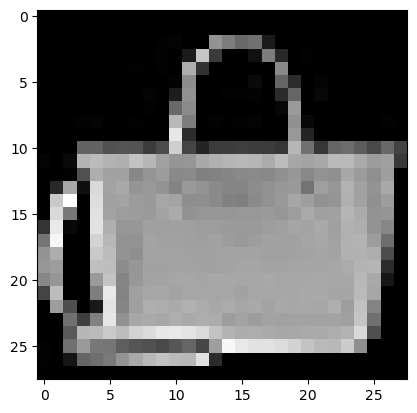

In [49]:
import matplotlib.pyplot as plt

plt.imshow(
    val_scaled[0].reshape(28, 28), # 2차원 데이터로 변경
    cmap='gray'
)

plt.show()

In [ ]:
val_scaled[0:1] # 범위를 지정해 슬라이싱 진행한 것은 한 차원을 추가로 생성한다

array([[[[  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0]],

        [[  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0]],

        [[  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
    

In [50]:
pred = model.predict(val_scaled[:1])
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


array([[3.0570653e-21, 7.6861520e-32, 2.0950445e-22, 1.6164110e-25,
        1.2357827e-22, 1.3742227e-19, 6.2690306e-21, 2.9385956e-20,
        1.0000000e+00, 3.1958414e-22]], dtype=float32)

In [51]:
# 글자로 변경하기
# softmax에서는 숫자값만 반환하기 때문에
import numpy as np
classes = [
    '티셔츠', 
    '바지', 
    '스웨터', 
    '드레스',
    '코트',
    '샌달',
    '셔츠',
    '스니커즈',
    '가방',
    '앵글부츠'
]
len(classes)

10

In [52]:
classes[np.argmax(pred)]

'가방'

#### test data로 확인하기

In [53]:
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0
model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9146 - loss: 0.2444


[0.24444040656089783, 0.9146000146865845]